In [17]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames[:5]:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/sample_submission.csv
/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/train.csv
/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/test.csv
/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images/32258b566bba41018fbfbc8cce95d6dc.png
/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images/c653d938386447e58ab9a53f7100fa46.png
/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images/1760d71394de469aa5fb39efbeee905b.png
/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images/eca6f027f8df442b9d7ff417f9f44f9d.png
/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images/eb307364f199495a90644e1834572135.png


**Imports and setup**

In [18]:
# Imports
import torch
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset, WeightedRandomSampler
import os
import random
import copy
import time
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score
from torchvision import transforms, models
from sklearn.model_selection import StratifiedKFold

In [19]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

**LOAD DATA & CREATE LABELS**

In [20]:
import pandas as pd
import numpy as np



In [21]:
# Environment check
print(f"Pytorch version: {torch.__version__}")
print(f"Cuda available: {torch.cuda.is_available()}")

# Only query CUDA details when a GPU is available.
if torch.cuda.is_available():
    print(f"Cuda version: {torch.version.cuda}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Pytorch version: 2.10.0+cu128
Cuda available: True
Cuda version: 12.8
GPU Device: Tesla T4
Using device: cuda


In [22]:
# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

**Initial Data Inspection****

In [23]:
# Data paths 
train_df = pd.read_csv("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/test.csv")
images_path = "/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images"

In [24]:
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (51043, 21)
Test shape: (17015, 1)


In [25]:
# Dataset overview
print("Dataset Overview\n")
print(f"Number of training samples: {len(train_df):,}")
print(f"Number of test samples: {len(test_df):,}")

# Treat every non-ID column in train.csv as a target label.
label_cols = [col for col in train_df.columns if col != "id"]

print(f"Number of classes: {len(label_cols)}")
print(f"\nClasses:\n{label_cols}")

Dataset Overview

Number of training samples: 51,043
Number of test samples: 17,015
Number of classes: 20

Classes:
['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'Pneumoperitoneum', 'Pneumomediastinum', 'Subcutaneous Emphysema', 'Tortuous Aorta', 'Calcification of the Aorta', 'No Finding']


In [26]:
# Label distribution
# Summarize how often each class appears in the training set.
label_summary = pd.DataFrame({
    "positive_count": train_df[label_cols].sum().astype(int)
}).sort_values("positive_count", ascending=False)

label_summary["positive_percentage"] = (
    100 * label_summary["positive_count"] / len(train_df)
).round(3)

print(f"Label Summary:\n")
print(label_summary)

Label Summary:

                            positive_count  positive_percentage
No Finding                           34079               66.765
Infiltration                          5206               10.199
Atelectasis                           2351                4.606
Effusion                              2156                4.224
Nodule                                1527                2.992
Mass                                  1249                2.447
Pneumothorax                          1114                2.182
Consolidation                          651                1.275
Pleural_Thickening                     608                1.191
Cardiomegaly                           600                1.175
Fibrosis                               389                0.762
Edema                                  326                0.639
Tortuous Aorta                         254                0.498
Emphysema                              172                0.337
Pneumonia               

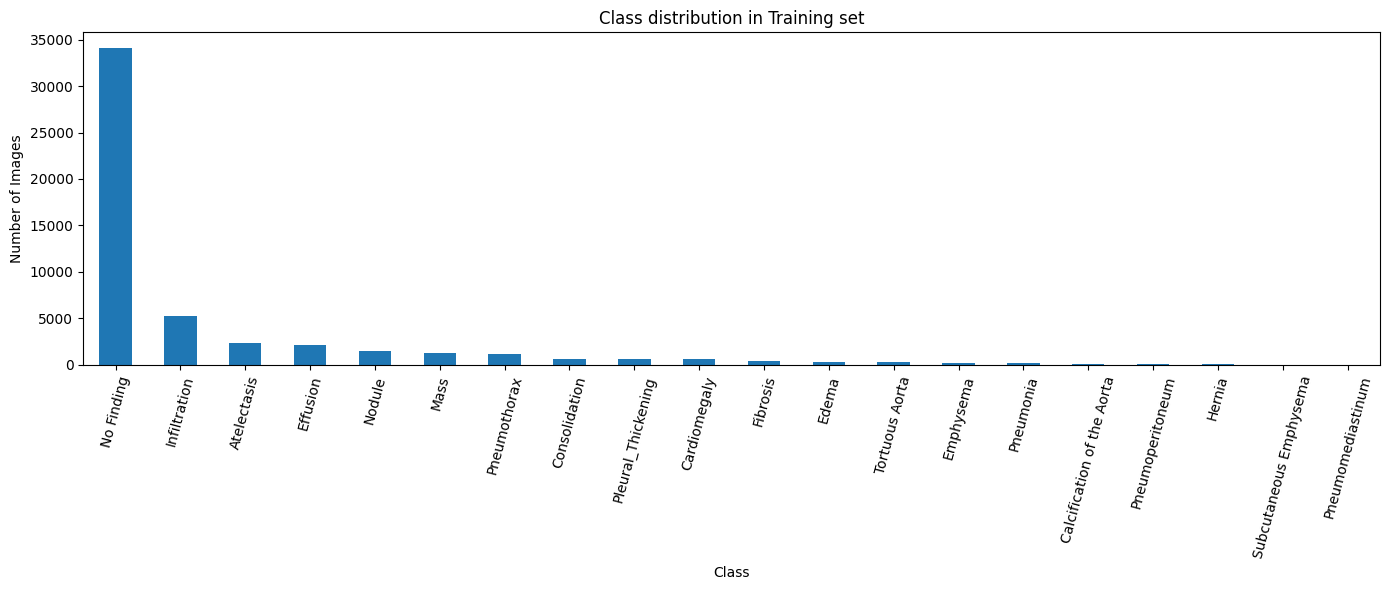

In [27]:
# Plot class distribution
# Visualize class imbalance across the training labels.
plt.figure(figsize=(14,6))
label_summary["positive_count"].plot(kind="bar")
plt.title("Class distribution in Training set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [28]:
# Class imbalance
# Highlight the most and least frequent classes for a quick imbalance check.
most_common = label_summary.index[0]
least_common = label_summary.index[-1]

print("Observations on class distribution:\n")
print(f"Most common class: {most_common} (with {label_summary.iloc[0]['positive_count']:,} samples)")
print(f"Least common class: {least_common} (with {label_summary.iloc[-1]['positive_count']:,} samples)")

Observations on class distribution:

Most common class: No Finding (with 34,079.0 samples)
Least common class: Pneumomediastinum (with 5.0 samples)


**Image Path Validation**

In [29]:
# Image paths
# Build full image paths and verify that the referenced files exist.
def get_image_path(image_id):
    return os.path.join(images_path, image_id)

# Check whether files exist
train_df["image_path"] = train_df["id"].apply(get_image_path)
test_df["image_path"] = test_df["id"].apply(get_image_path)

train_exists = train_df["image_path"].apply(os.path.exists)
test_exists = test_df["image_path"].apply(os.path.exists)


print("Image Path Audit")
print(f"Train images found: {train_exists.sum():,} / {len(train_df):,}")
print(f"Test images found : {test_exists.sum():,} / {len(test_df):,}")

if (~train_exists).sum() > 0:
    print("\nMissing train image examples:")
    print(train_df.loc[~train_exists, ["id", "image_path"]].head())

if (~test_exists).sum() > 0:
    print("\nMissing test image examples:")
    print(test_df.loc[~test_exists, ["id", "image_path"]].head())

Image Path Audit
Train images found: 51,043 / 51,043
Test images found : 17,015 / 17,015


**Sample Image Visualization**

Sampled Image Properties
Image modes:
mode
RGB    200
Name: count, dtype: int64

Width summary:
count    200.0
mean     384.0
std        0.0
min      384.0
25%      384.0
50%      384.0
75%      384.0
max      384.0
Name: width, dtype: float64

Height summary:
count    200.0
mean     384.0
std        0.0
min      384.0
25%      384.0
50%      384.0
75%      384.0
max      384.0
Name: height, dtype: float64


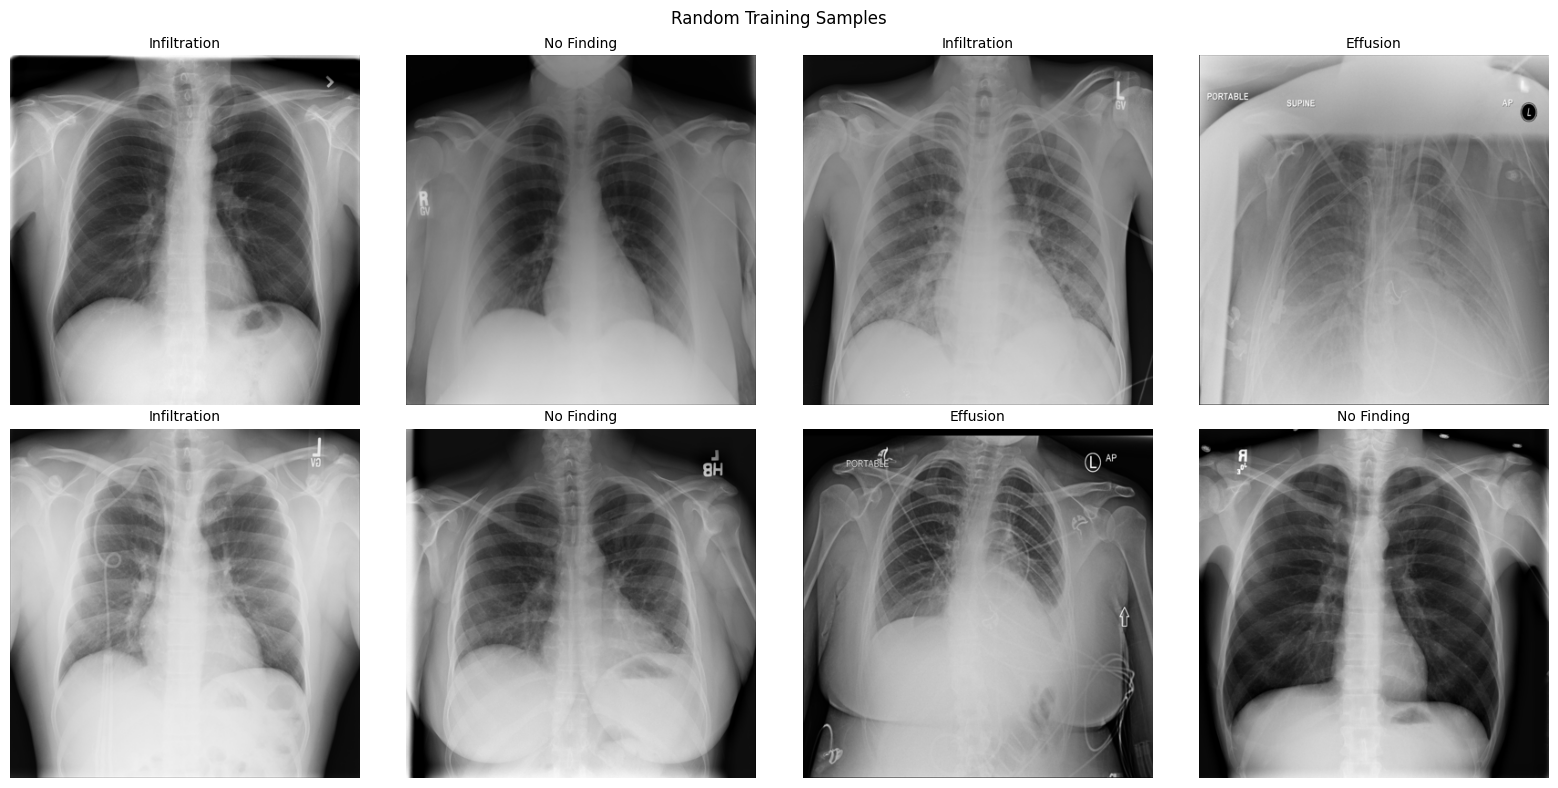

In [30]:
# Image sample audit
# Sample image files and inspect their basic properties.
sample_n = 200
sample_paths = train_df.loc[train_exists, "image_path"].sample(sample_n, random_state=42).tolist()

image_info = []

for path in sample_paths:
    try:
        with Image.open(path) as img:
            image_info.append({
                "path": path,
                "mode": img.mode,      # e.g. "L", "RGB"
                "width": img.width,
                "height": img.height
            })
    except Exception as e:
        image_info.append({
            "path": path,
            "mode": "ERROR",
            "width": None,
            "height": None
        })

image_info_df = pd.DataFrame(image_info)

print("Sampled Image Properties")
print("Image modes:")
print(image_info_df["mode"].value_counts(dropna=False))

print("\nWidth summary:")
print(image_info_df["width"].describe())

print("\nHeight summary:")
print(image_info_df["height"].describe())
# Sample visualization
# Display random training images with their labels.
def get_label_name(row, label_cols):
    return row[label_cols].idxmax()

sample_rows = train_df.sample(8, random_state=42).reset_index(drop=True)

plt.figure(figsize=(16, 8))
for i in range(len(sample_rows)):
    row = sample_rows.iloc[i]
    img_path = row["image_path"]
    label_name = get_label_name(row, label_cols)

    plt.subplot(2, 4, i + 1)
    try:
        with Image.open(img_path) as img:
            plt.imshow(img, cmap="gray" if img.mode == "L" else None)
            plt.title(label_name, fontsize=10)
            plt.axis("off")
    except Exception:
        plt.text(0.1, 0.5, "Error loading image", fontsize=10)
        plt.axis("off")

plt.suptitle("Random Training Samples")
plt.tight_layout()
plt.show()

**Label Encoding**

In [31]:
# Label encoding
# Convert one-hot labels to class indices and build lookup mappings.
n_classes = len(label_cols)

train_df["label_idx"] = train_df[label_cols].values.argmax(axis=1)

class_to_idx = {label: idx for idx, label in enumerate(label_cols)}
idx_to_class = {idx: label for label, idx in class_to_idx.items()}

print(f"Label encoding ready.\nNumber of classes: {n_classes}")

Label encoding ready.
Number of classes: 20


**Evaluation Metric**

In [32]:
# competiton metric

def competition_macro_score(y_true, y_pred, n_classes):
    """
    Computes the competition's macro-averaged asymmetric score.

    Score_c = (TP_c - FP_c - 5*FN_c) / N_c

    where,
     (TP_c) = True positives for class (c)
     (FP_c) = False positives for class (c)
     (FN_c) = False negatives for class (c)
     (N_c) = Number of true samples for class (c)

    """
    class_scores = []

    for c in range(n_classes):
        true_c = (y_true == c)
        pred_c = (y_pred == c)

        tp = np.sum(true_c & pred_c)
        fp = np.sum(~true_c & pred_c)
        fn = np.sum(true_c & ~pred_c)
        n_c = np.sum(true_c)

        # Safety check: skip impossible empty class in validation
        if n_c == 0:
            continue

        score_c = (tp - fp - 5 * fn) / n_c
        class_scores.append(score_c)

    return np.mean(class_scores)
# Dummy baseline
# Benchmark the metric with a constant prediction.
y_all = train_df["label_idx"].values
no_finding_idx = class_to_idx["No Finding"]
y_pred_dummy = np.full_like(y_all, fill_value=no_finding_idx)

dummy_score = competition_macro_score(y_all, y_pred_dummy, n_classes)

print("Dummy Baseline")
print(f"Always predicting 'No Finding' gives score: {dummy_score:.5f}")


Dummy Baseline
Always predicting 'No Finding' gives score: -4.72489


In [34]:
# Cross-validation setup
# StratifiedKFold preserves class proportion across folds.

N_SPLITS = 3

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

fold_summaries = []
for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df["label_idx"]), start=1):
    fold_train = train_df.iloc[train_idx]
    fold_val = train_df.iloc[val_idx]

    train_counts = fold_train["label_idx"].value_counts().sort_index()
    val_counts = fold_val["label_idx"].value_counts().sort_index()

    fold_summaries.append({
        "fold": fold,
        "train_size": len(fold_train),
        "val_size": len(fold_val),
        "min_train_class_count": int(train_counts.min()),
        "min_val_class_count": int(val_counts.min()),
        "max_train_class_count": int(train_counts.max()),
        "max_val_class_count": int(val_counts.max()),
    })

fold_summary_df = pd.DataFrame(fold_summaries)

print(f"Cross-validation fold summary\n{fold_summary_df}")
# Fold indices
# Materialize the fold splits for reuse later in training.
all_folds = list(skf.split(train_df, train_df["label_idx"]))

Cross-validation fold summary
   fold  train_size  val_size  min_train_class_count  min_val_class_count  \
0     1       34028     17015                      3                    2   
1     2       34029     17014                      4                    1   
2     3       34029     17014                      3                    2   

   max_train_class_count  max_val_class_count  
0                  22719                11360  
1                  22719                11360  
2                  22720                11359  


**Image preprocessing**

In [35]:
# Image transforms
# Define preprocessing for training and validation images.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=7),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet mean
        std=[0.229, 0.224, 0.225]     # ImageNet std
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("\nTransforms ready.")
print("Train transform: resize + light augmentation + normalization")
print("Val transform  : resize + normalization")


Transforms ready.
Train transform: resize + light augmentation + normalization
Val transform  : resize + normalization


In [36]:
# Dataset class
# Load images and return either labels or image IDs, depending on the split.
class ChestXrayDataset(Dataset):
    def __init__(self, df, images_path, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.images_path = images_path
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = row["id"]
        image_path = os.path.join(self.images_path, image_id)

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        if self.is_test:
            return image, image_id

        label = torch.tensor(int(row["label_idx"]), dtype=torch.long)
        return image, label

**Training Configuration**

In [38]:
# Training config

EXPERIMENT_NAME = "resnet18_adam_sqrtweightedce_nosampler"

MODEL_NAME = "resnet18"
OPTIMIZER_NAME = "adam"
LOSS_NAME = "sqrt_weighted_ce"
USE_WEIGHTED_SAMPLER = False

LR = 1e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 5

In [40]:
# Model setup
# Build the model, loss function, and optimizer from the experiment config.

def build_model(model_name, n_classes):
    if model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, n_classes)
    
    elif model_name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, n_classes)
    
    else:
        raise ValueError(f"{MODEL_NAME} not supported.")
    
    return model.to(device)


# Loss function
def build_criterion(loss_name, fold_train_df, device):
    if loss_name == "plain_ce":
        return nn.CrossEntropyLoss()
    elif loss_name == "sqrt_weighted_ce":
        # Derive class weights from the fold label counts.
        class_counts = (fold_train_df["label_idx"].value_counts().sort_index().reindex(range(n_classes), fill_value=0).values.astype(np.float32))
        
        class_weights = 1.0 / np.sqrt(np.maximum(class_counts, 1.0))
        class_weights = class_weights / class_weights.mean()
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

        print("Using sqrt-weighted CE")
        print("Class weights:", class_weights.detach().cpu().numpy())

        return nn.CrossEntropyLoss(weight=class_weights)
    else:
        raise ValueError(f"Unsupported loss_name: {loss_name}")
        

# Optimizer
def build_optimizer(model, optimizer_name, lr, weight_decay):
    if optimizer_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr)
    
    elif optimizer_name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    else:
        raise ValueError(f"Unknown OPTIMIZER_NAME: {optimizer_name}")
    
    print(f"Optimizer: {optimizer_name}")
    print(f"LR       : {lr}")
    if optimizer_name == "adamw":
        print(f"Weight decay: {weight_decay}")

In [41]:
# Training and inference loops
# Fuctions for running one training epoch, one validation epoch, and test-time inference.
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        if batch_idx % 100 == 0:
            print(f"  [Train] Batch {batch_idx:4d}/{len(loader)} | Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_score = competition_macro_score(
        np.array(all_labels),
        np.array(all_preds),
        n_classes
    )

    return epoch_loss, epoch_acc, epoch_score


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_logits = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        all_logits.append(outputs.detach().cpu())
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    all_logits = torch.cat(all_logits, dim=0).numpy()
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_score = competition_macro_score(all_labels, all_preds, n_classes)

    return epoch_loss, epoch_acc, epoch_score, all_labels, all_preds, all_logits


# inference function for test logits
@torch.no_grad()
def predict_test_logits(model, loader, device):
    model.eval()

    all_logits = []
    all_ids = []

    for batch_idx, (images, image_ids) in enumerate(loader):
        images = images.to(device, non_blocking=True)

        outputs = model(images)   # raw logits
        all_logits.append(outputs.detach().cpu())
        all_ids.extend(list(image_ids))

        if batch_idx % 100 == 0:
            print(f"  [Test] Batch {batch_idx:4d}/{len(loader)}")

    all_logits = torch.cat(all_logits, dim=0).numpy()
    return all_ids, all_logits

In [44]:
# Bias tuning
# Greedily searches per-class logit offsets to improve the competition score.

def tune_class_biases_greedy(logits, y_true, n_classes, bias_values=None, num_passes=2):
    if bias_values is None:
        bias_values = [-1.5, -1.0, -0.7, -0.5, -0.3, 0.0, 0.3, 0.5]

    bias = np.zeros(n_classes, dtype=np.float32)
    best_score = competition_macro_score(y_true, logits.argmax(axis=1), n_classes)

    print(f"Initial score: {best_score:.6f}")

    for p in range(num_passes):
        print(f"\nPass {p + 1}/{num_passes}")
        improved_any = False

        for c in range(n_classes):
            current_best_bias = bias[c]
            current_best_score = best_score

            for val in bias_values:
                trial_bias = bias.copy()
                trial_bias[c] = val

                trial_preds = (logits + trial_bias).argmax(axis=1)
                trial_score = competition_macro_score(y_true, trial_preds, n_classes)

                if trial_score > current_best_score:
                    current_best_score = trial_score
                    current_best_bias = val

            if current_best_bias != bias[c]:
                print(
                    f"  Improved class {c:2d} ({idx_to_class[c]:30s}) "
                    f"bias {bias[c]:.2f} -> {current_best_bias:.2f} | "
                    f"score {best_score:.6f} -> {current_best_score:.6f}"
                )
                bias[c] = current_best_bias
                best_score = current_best_score
                improved_any = True

        if not improved_any:
            print("  No further improvements in this pass.")
            break

    final_preds = (logits + bias).argmax(axis=1)
    return bias, final_preds, best_score

In [45]:
# Cross-validation training
# Train one model per fold, tune validation-time class biases, and collect test logits.

EPOCHS = 5
BATCH_SIZE = 32
NUM_WORKERS = 2

fold_results = []
all_fold_test_logits = []
test_ids_reference = None

for fold_num, (train_idx, val_idx) in enumerate(all_folds, start=1):
    print(f"FOLD {fold_num}")

    fold_train_df = train_df.iloc[train_idx].reset_index(drop=True).copy()
    fold_val_df = train_df.iloc[val_idx].reset_index(drop=True).copy()

    print(f"Fold train size: {len(fold_train_df):,}")
    print(f"Fold val size  : {len(fold_val_df):,}")

    # Build datasets and loaders for the current fold.
    train_dataset = ChestXrayDataset(
        df=fold_train_df,
        images_path=images_path,
        transform=train_transform,
        is_test = False
    )

    val_dataset = ChestXrayDataset(
        df=fold_val_df,
        images_path=images_path,
        transform=val_transform,
        is_test = False
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    # Reinitialize training components for each fold.
    model = build_model(MODEL_NAME, n_classes).to(device)
    criterion = build_criterion(LOSS_NAME, fold_train_df, device)
    optimizer = build_optimizer(model, OPTIMIZER_NAME, LR, WEIGHT_DECAY)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1
    )

    # Track per-epoch training and validation metrics.
    history = {
        "train_loss": [],
        "train_acc": [],
        "train_score": [],
        "val_loss": [],
        "val_acc": [],
        "val_score": []
    }

    best_val_score = -np.inf
    best_model_state = copy.deepcopy(model.state_dict())
    best_y_val_true = None
    best_y_val_pred = None
    best_val_logits = None
    best_epoch = None

    for epoch in range(1, EPOCHS + 1):
        start_time = time.time()
        print(f"\nEpoch {epoch}/{EPOCHS}")

        train_loss, train_acc, train_score = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc, val_score, y_val_true, y_val_pred, val_logits = validate_one_epoch(
            model, val_loader, criterion, device
        )

        scheduler.step(val_score)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_score"].append(train_score)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_score"].append(val_score)

        epoch_time = time.time() - start_time

        print(f"Train Loss : {train_loss:.4f}")
        print(f"Train Acc  : {train_acc:.4f}")
        print(f"Train Score: {train_score:.4f}")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val Acc    : {val_acc:.4f}")
        print(f"Val Score  : {val_score:.4f}")
        print(f"LR         : {optimizer.param_groups[0]['lr']:.6f}")
        print(f"Time       : {epoch_time:.1f} sec")

        if val_score > best_val_score:
            best_val_score = val_score
            best_model_state = copy.deepcopy(model.state_dict())
            best_y_val_true = y_val_true.copy()
            best_y_val_pred = y_val_pred.copy()
            best_val_logits = val_logits.copy()
            best_epoch = epoch
            print("Best model updated.")

    print(f"\nBest raw val score for fold {fold_num}: {best_val_score:.6f} at epoch {best_epoch}")

    # Restore the best checkpoint before fold-level bias tuning and test inference.
    model.load_state_dict(best_model_state)

    best_bias, tuned_val_preds, tuned_val_score = tune_class_biases_greedy(
        best_val_logits,
        best_y_val_true,
        n_classes,
        bias_values=[-1.5, -1.0, -0.7, -0.5, -0.3, 0.0, 0.3],
        num_passes=3
    )

    print(f"Fold {fold_num} tuned val score: {tuned_val_score:.6f}")

    # Run test inference with the best model from this fold.
    test_dataset = ChestXrayDataset(
        df=test_df,
        images_path=images_path,
        transform=val_transform,
        is_test=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    fold_test_ids, fold_test_logits = predict_test_logits(model, test_loader, device)

    # Keep a single shared test ID order across folds.
    if test_ids_reference is None:
        test_ids_reference = fold_test_ids
    else:
        assert test_ids_reference == fold_test_ids, "Test IDs order mismatch across folds!"

    adjusted_fold_test_logits = fold_test_logits + best_bias
    all_fold_test_logits.append(adjusted_fold_test_logits)

    fold_results.append({
        "fold": fold_num,
        "best_raw_val_score": best_val_score,
        "best_tuned_val_score": tuned_val_score,
        "best_epoch": best_epoch,
        "best_bias": best_bias
    })

    print(f"Finished fold {fold_num}")
# Fold summary
# Summarize the best validation scores from each fold.
fold_results_df = pd.DataFrame([
    {
        "fold": x["fold"],
        "best_epoch": x["best_epoch"],
        "best_raw_val_score": x["best_raw_val_score"],
        "best_tuned_val_score": x["best_tuned_val_score"]
    }
    for x in fold_results
])

print(fold_results_df)
print("\nMean raw val score  :", fold_results_df["best_raw_val_score"].mean())
print("Mean tuned val score:", fold_results_df["best_tuned_val_score"].mean())

FOLD 1
Fold train size: 34,028
Fold val size  : 17,015
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 161MB/s] 


Using sqrt-weighted CE
Class weights: [0.24506947 0.48505804 0.4656706  0.65704554 0.25591475 0.90859693
 0.6016404  1.9402322  0.16468686 0.33612528 0.30405334 0.48146054
 0.9378466  0.3561408  1.7711815  5.6009674  2.42529    0.7462431
 1.2524145  0.06436194]

Epoch 1/5
  [Train] Batch    0/1064 | Loss: 3.0855
  [Train] Batch  100/1064 | Loss: 2.4346
  [Train] Batch  200/1064 | Loss: 1.9995
  [Train] Batch  300/1064 | Loss: 3.0277
  [Train] Batch  400/1064 | Loss: 2.3867
  [Train] Batch  500/1064 | Loss: 2.3024
  [Train] Batch  600/1064 | Loss: 2.1602
  [Train] Batch  700/1064 | Loss: 2.2108
  [Train] Batch  800/1064 | Loss: 1.6265
  [Train] Batch  900/1064 | Loss: 2.3967
  [Train] Batch 1000/1064 | Loss: 2.1006
Train Loss : 2.2577
Train Acc  : 0.5940
Train Score: -5.1897
Val Loss   : 2.1365
Val Acc    : 0.5758
Val Score  : -4.7431
LR         : 0.000100
Time       : 473.8 sec
Best model updated.

Epoch 2/5
  [Train] Batch    0/1064 | Loss: 2.0354
  [Train] Batch  100/1064 | Loss: 2.2

In [46]:
# Submission assembly
# Average fold logits, convert them to one-hot predictions, and save the submission file.

ensemble_test_logits = np.mean(np.stack(all_fold_test_logits, axis=0), axis=0)
ensemble_test_pred_indices = ensemble_test_logits.argmax(axis=1)

submission_array = np.zeros((len(test_ids_reference), len(label_cols)), dtype=np.int64)
submission_array[np.arange(len(test_ids_reference)), ensemble_test_pred_indices] = 1

submission_df = pd.DataFrame(submission_array, columns=label_cols)
submission_df.insert(0, "id", test_ids_reference)

print("Submission shape:", submission_df.shape)
print("Unique row sums:", submission_df[label_cols].sum(axis=1).unique())

print("\nPrediction counts by class:")
print(submission_df[label_cols].sum(axis=0).sort_values(ascending=False))

submission_df.to_csv("submission.csv", index=False)

print(f"\nSaved the final submission!")

Submission shape: (17015, 21)
Unique row sums: [1]

Prediction counts by class:
No Finding                    13290
Effusion                       1105
Infiltration                    975
Atelectasis                     612
Pneumothorax                    462
Mass                            236
Nodule                          157
Cardiomegaly                    156
Edema                            18
Fibrosis                          3
Tortuous Aorta                    1
Consolidation                     0
Pleural_Thickening                0
Hernia                            0
Emphysema                         0
Pneumonia                         0
Pneumomediastinum                 0
Pneumoperitoneum                  0
Subcutaneous Emphysema            0
Calcification of the Aorta        0
dtype: int64

Saved the final submission!
